In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st

In [2]:
data = pd.read_csv("data/salary_data.csv")
X = data["YearsExperience"]
y = data["Salary"]

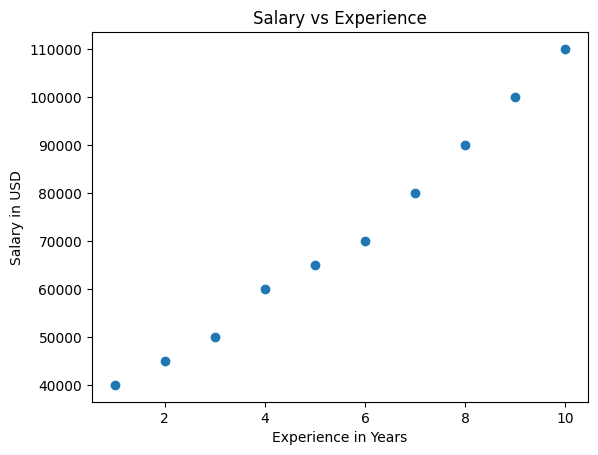

In [3]:
plt.scatter(X,y)
plt.xlabel("Experience in Years")
plt.ylabel("Salary in USD")
plt.title("Salary vs Experience")
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X_vector = X.values.reshape(-1, 1)
model.fit(X_vector,y)
y_hat = model.predict(X_vector)
print("Slope: ", model.coef_)
print("Intercept:", model.intercept_)

Slope:  [7757.57575758]
Intercept: 28333.33333333333


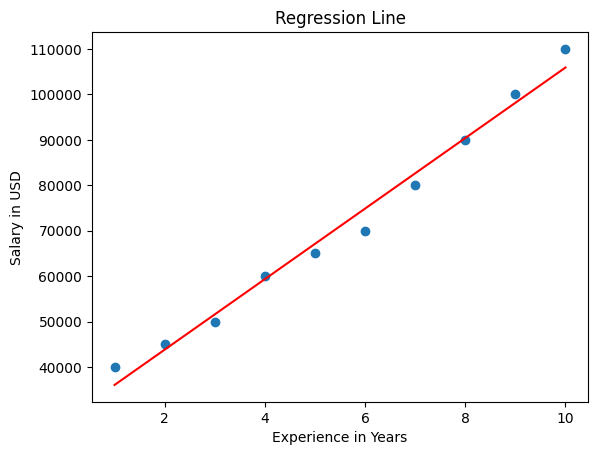

In [5]:
plt.scatter(X,y)
plt.plot(X,y_hat, color='red')
plt.xlabel("Experience in Years")
plt.ylabel("Salary in USD")
plt.title("Regression Line")
plt.show()

In [6]:
#Evaluate model
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y, y_hat))

R2 Score: 0.9850889850889851


In [10]:
# Save m and b to a file or module
with open("src/coefficients.py", "w") as f:
    f.write(f"m = {m}\nb = {b}\n")

FileNotFoundError: [Errno 2] No such file or directory: 'src/coefficients.py'

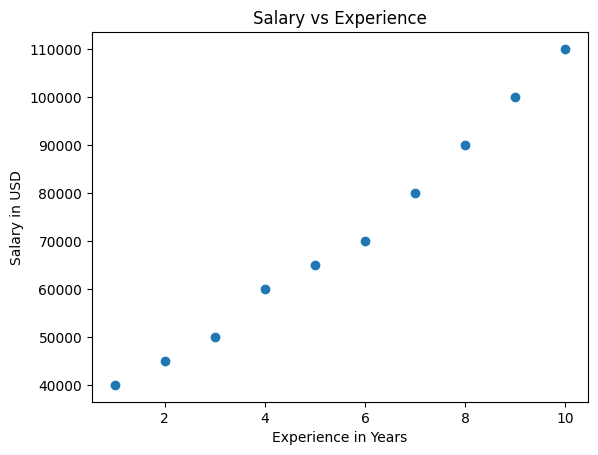

Iteration    0: Cost 1072035506.25   
Iteration  150: Cost 44152672.10   
Iteration  300: Cost 25258914.64   
Iteration  450: Cost 15202221.66   
Iteration  600: Cost 9849285.70   
Iteration  750: Cost 7000046.54   
Iteration  900: Cost 5483465.02   
Iteration 1050: Cost 4676225.13   
Iteration 1200: Cost 4246550.74   
Iteration 1350: Cost 4017845.39   
Slope: (w)  7921.244053351687
Intercept: (b)  27193.903730699327
(10,) (10,)


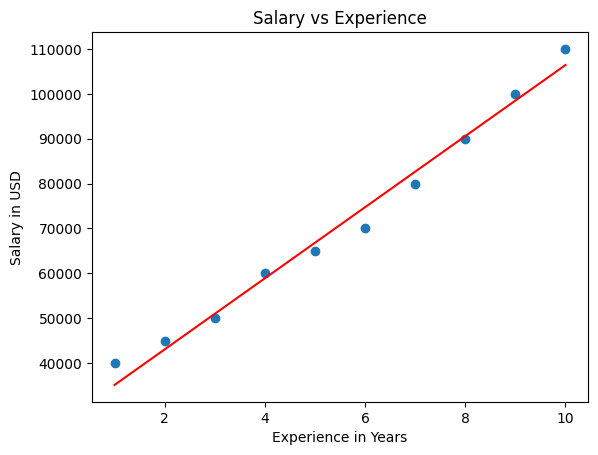

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
import math

## compute the cost of linear regression based on weight and bias.
def compute_cost(X,y,w,b):
    m = X.shape[0]
    total_cost = 0
    cost = 0
    for i in range(m):
        fwb_x = np.dot(w,X[i]) + b
        error = (fwb_x - y[i]) ** 2
        cost += error
    total_cost = (1/(2*m))*cost
    return total_cost
 
## compute gradient for given weight and bias.
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    dj_db = 0
    dj_dw = 0
    for i in range(m):
        error = (np.dot(w,X[i]) + b) - y[i]
        dj_db = dj_db + error
        dj_dw = dj_dw + error * X[i]
    dj_db = (1/m) * dj_db
    dj_dw = (1/m) * dj_dw
    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, num_iters):
    J_history = []
    w_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w = w - alpha * dj_dw ## adjust
        b = b - alpha * dj_db ## adjust
        J_history.append(compute_cost(X,y,w,b))
        w_history.append(w)
        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
    return w, b, J_history, w_history

data = pd.read_csv("data/salary_data.csv")
X = data["YearsExperience"]
y = data["Salary"]

plt.scatter(X,y)
plt.xlabel("Experience in Years")
plt.ylabel("Salary in USD")
plt.title("Salary vs Experience")
plt.show()

w,b,_,_ = gradient_descent(X,y,0,0,0.01,1500)
print("Slope: (w) ", w)
print("Intercept: (b) ", b)

m = X.shape[0]
y_hat = np.zeros(m)
for i in range(m):
    y_hat[i] = np.dot(w,X[i])+b

print(X.shape, y_hat.shape)
plt.scatter(X,y)
plt.plot(X,y_hat, color='red')
plt.xlabel("Experience in Years")
plt.ylabel("Salary in USD")
plt.title("Salary vs Experience")
plt.show()